#Data Exploration

In [1]:
!pip install -q datasets

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from datasets import load_dataset
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.figsize"] = (12, 5)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/twincar'
os.makedirs(PROJECT_ROOT, exist_ok=True)

Mounted at /content/drive


In [4]:
dataset = load_dataset('naufalso/stanford_cars',
                       cache_dir=f'{PROJECT_ROOT}/stanford_cars_cache')
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/614 [00:00<?, ?B/s]

DatasetDict({
    train: Dataset({
        features: ['image_path', 'x_min', 'y_min', 'x_max', 'y_max', 'label', 'car_name'],
        num_rows: 8103
    })
    test: Dataset({
        features: ['image_path', 'x_min', 'y_min', 'x_max', 'y_max', 'label', 'car_name'],
        num_rows: 8000
    })
})


In [5]:
df = pd.DataFrame(dataset['train'].select(range(10)))
df[['car_name', 'label', 'x_min', 'y_min', 'x_max', 'y_max']]

,car_name,label,x_min,y_min,x_max,y_max
0,Audi TTS Coupe 2012,14,39,116,569,375
1,Acura TL Sedan 2012,3,36,116,868,587
2,Dodge Dakota Club Cab 2007,91,85,109,601,381
3,Hyundai Sonata Hybrid Sedan 2012,134,621,393,1484,1096
4,Ford F-450 Super Duty Crew Cab 2012,106,14,36,133,99
5,Geo Metro Convertible 1993,123,259,289,515,416
6,Dodge Journey SUV 2012,89,88,80,541,397
7,Dodge Charger Sedan 2012,96,73,79,591,410
8,Mitsubishi Lancer Sedan 2012,167,20,126,1269,771
9,Chevrolet Traverse SUV 2012,58,21,110,623,367


In [6]:
print(dataset['train'][0]['image_path'])

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x400 at 0x7D11F2A10110>


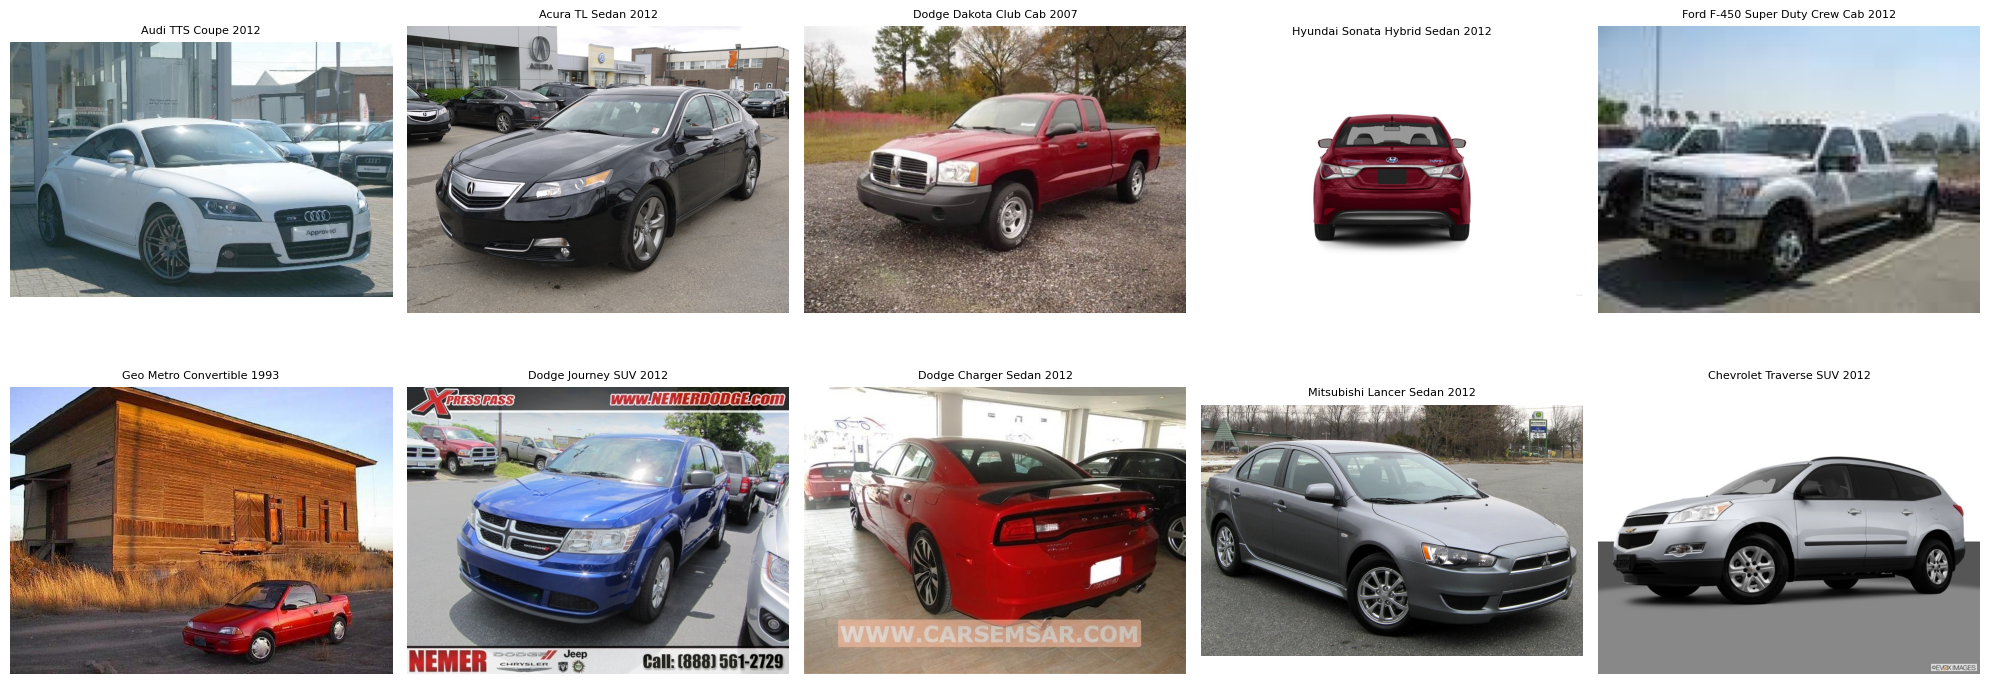

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i in range(10):
    img = dataset['train'][i]['image_path']
    name = dataset['train'][i]['car_name']
    axes[i].imshow(img)
    axes[i].set_title(name, fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [8]:
labels = dataset['train']['car_name']
counts = Counter(labels)

print(f'Unique classes: {len(counts)}')
print(f'Min images per class: {min(counts.values())}')
print(f'Max images per class: {max(counts.values())}')
print(f'Mean images per class: {sum(counts.values())/len(counts):.1f}')

Unique classes: 195
Min images per class: 24
Max images per class: 68
Mean images per class: 41.6


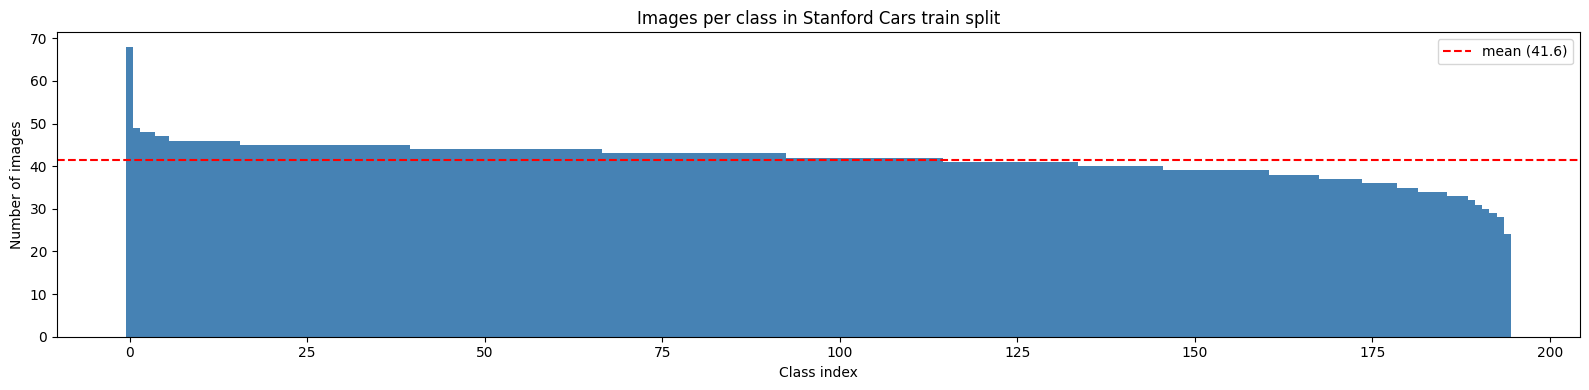

In [9]:
sorted_counts = sorted(counts.values(), reverse=True)
mean_count = np.mean(sorted_counts)

plt.figure(figsize=(16, 4))
plt.bar(range(len(sorted_counts)), sorted_counts, color='steelblue', width=1.0)
plt.title('Images per class in Stanford Cars train split')
plt.xlabel('Class index')
plt.ylabel('Number of images')
plt.axhline(
    y=mean_count,
    color='red',
    linestyle='--',
    label=f'mean ({mean_count:.1f})'
)
plt.legend()
plt.tight_layout()
plt.show()

# Image size distribution

In [10]:
sample = dataset['train'].select(range(500))
widths = [ex['image_path'].size[0] for ex in sample]
heights = [ex['image_path'].size[1] for ex in sample]

print(f'Width  - min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'Height - min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')

Width  - min: 78, max: 3699, mean: 713
Height - min: 58, max: 2775, mean: 494


- The Stanford Cars images have very different resolutions, from very small images to high-resolution photos.
- Because neural networks require fixed-size tensors, all images must be standardized before training.
- For the first baseline, we will use a pretrained model with a 224×224 input size.
- To avoid unnecessary distortion, the preferred preprocessing strategy is aspect-ratio-aware resizing followed by cropping, instead of blindly stretching every image.
- **Conclusion: image resizing is required before training, and the model input size will be 224×224.**

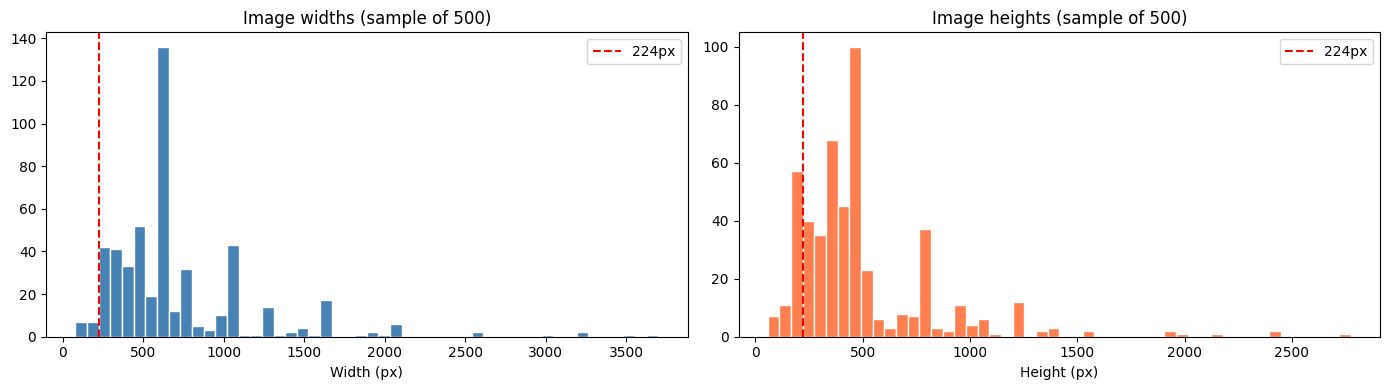

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(widths, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Image widths (sample of 500)')
axes[0].set_xlabel('Width (px)')
axes[0].axvline(x=224, color='red', linestyle='--', label='224px')
axes[0].legend()

axes[1].hist(heights, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Image heights (sample of 500)')
axes[1].set_xlabel('Height (px)')
axes[1].axvline(x=224, color='red', linestyle='--', label='224px')
axes[1].legend()

plt.tight_layout()
plt.show()

- Most images are between 400–700px wide, with 224px falling on the lower end
- A small cluster of very high resolution outliers (2000–3500px) exists but is rare
- **Conclusion: we will resize all images to 224x224 during preprocessing**

#Parsing Car Names into Make, Model, Year

Each class label in Stanford Cars follows a pattern similar to:

`Make Model BodyType Year`

Example:

`Audi TTS Coupe 2012`

For our project, the mandatory prediction target is make and model. The year is optional.

One important detail is that some car makes contain multiple words, for example:

- `AM General`
- `Aston Martin`
- `Land Rover`

Because of that, we cannot simply take the first word as the make. We need a small parsing function that handles these known multi-word makes correctly.

In [12]:
MULTI_WORD_MAKES = [
    "AM General",
    "Aston Martin",
    "Land Rover"
]

def parse_car_name(name):
    """
    Parse a Stanford Cars class name into make, model, and year.

    Example:
        "Audi TTS Coupe 2012"
        -> make="Audi", model="TTS Coupe", year="2012"

        "Aston Martin V8 Vantage Convertible 2012"
        -> make="Aston Martin", model="V8 Vantage Convertible", year="2012"
    """
    name = name.strip()
    tokens = name.split()

    if tokens[-1].isdigit():
        year = tokens[-1]
        name_without_year = " ".join(tokens[:-1])
    else:
        year = None
        name_without_year = name

    for make_candidate in MULTI_WORD_MAKES:
        if name_without_year.startswith(make_candidate + " "):
            make = make_candidate
            model = name_without_year.replace(make_candidate + " ", "", 1)
            return make, model, year

    tokens_without_year = name_without_year.split()
    make = tokens_without_year[0]
    model = " ".join(tokens_without_year[1:])

    return make, model, year


parsed = [parse_car_name(name) for name in dataset['train']['car_name']]

makes = [p[0] for p in parsed]
models = [p[1] for p in parsed]
years = [p[2] for p in parsed]

print(f"Unique makes: {len(set(makes))}")
print(f"Unique models: {len(set(models))}")
print(f"Unique years: {len(set(years))}")

valid_years = [y for y in years if y is not None]
print(f"\nYear range: {min(valid_years)} - {max(valid_years)}")

print("\nTop 10 makes by number of images:")
for make, count in Counter(makes).most_common(10):
    print(f"  {make}: {count}")

print("\nMulti-word makes found:")
for make in MULTI_WORD_MAKES:
    print(f"  {make}: {Counter(makes)[make]} images")

Unique makes: 48
Unique models: 188
Unique years: 16

Year range: 1991 - 2012

Top 10 makes by number of images:
  Chevrolet: 905
  Dodge: 630
  Audi: 589
  BMW: 531
  Ford: 521
  Hyundai: 438
  Mercedes-Benz: 261
  Chrysler: 260
  Acura: 242
  GMC: 238

Multi-word makes found:
  AM General: 45 images
  Aston Martin: 157 images
  Land Rover: 86 images


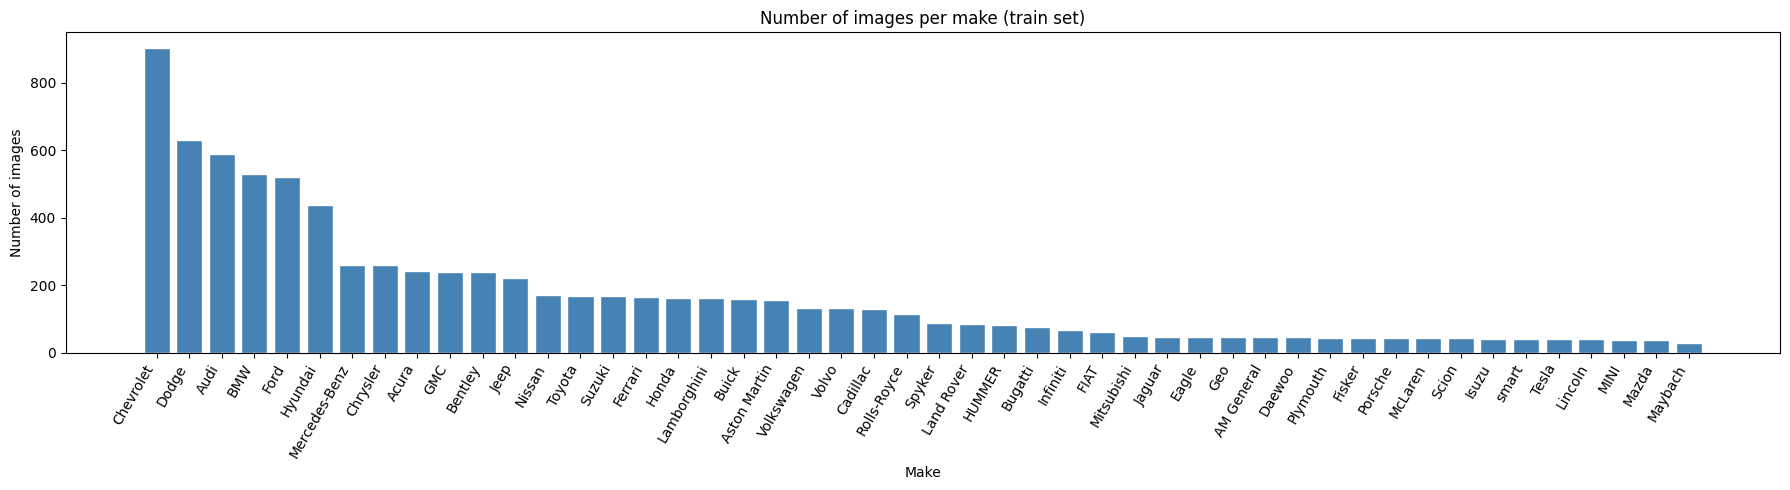

In [13]:
make_counts = Counter(makes)
make_sorted = sorted(make_counts, key=make_counts.get, reverse=True)

plt.figure(figsize=(18, 5))
plt.bar(make_sorted, [make_counts[m] for m in make_sorted], color='steelblue', edgecolor='white')
plt.title('Number of images per make (train set)')
plt.xlabel('Make')
plt.ylabel('Number of images')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

### Observations

- The dataset contains make/model/year labels, which match the main TwinCar requirement.
- Some makes are much more represented than others, especially brands such as Chevrolet, Dodge, Audi, BMW, and Ford.
- Some luxury or rare brands have fewer examples.
- The production years are mostly older vehicles, up to 2012, so the model may not generalize well to very new car models.
- For the mandatory project scope, we will focus on make/model classification. Year prediction will remain optional.

#Sample Images by Make
One representative image per car make to visually confirm label quality and get a sense of the visual diversity across brands.

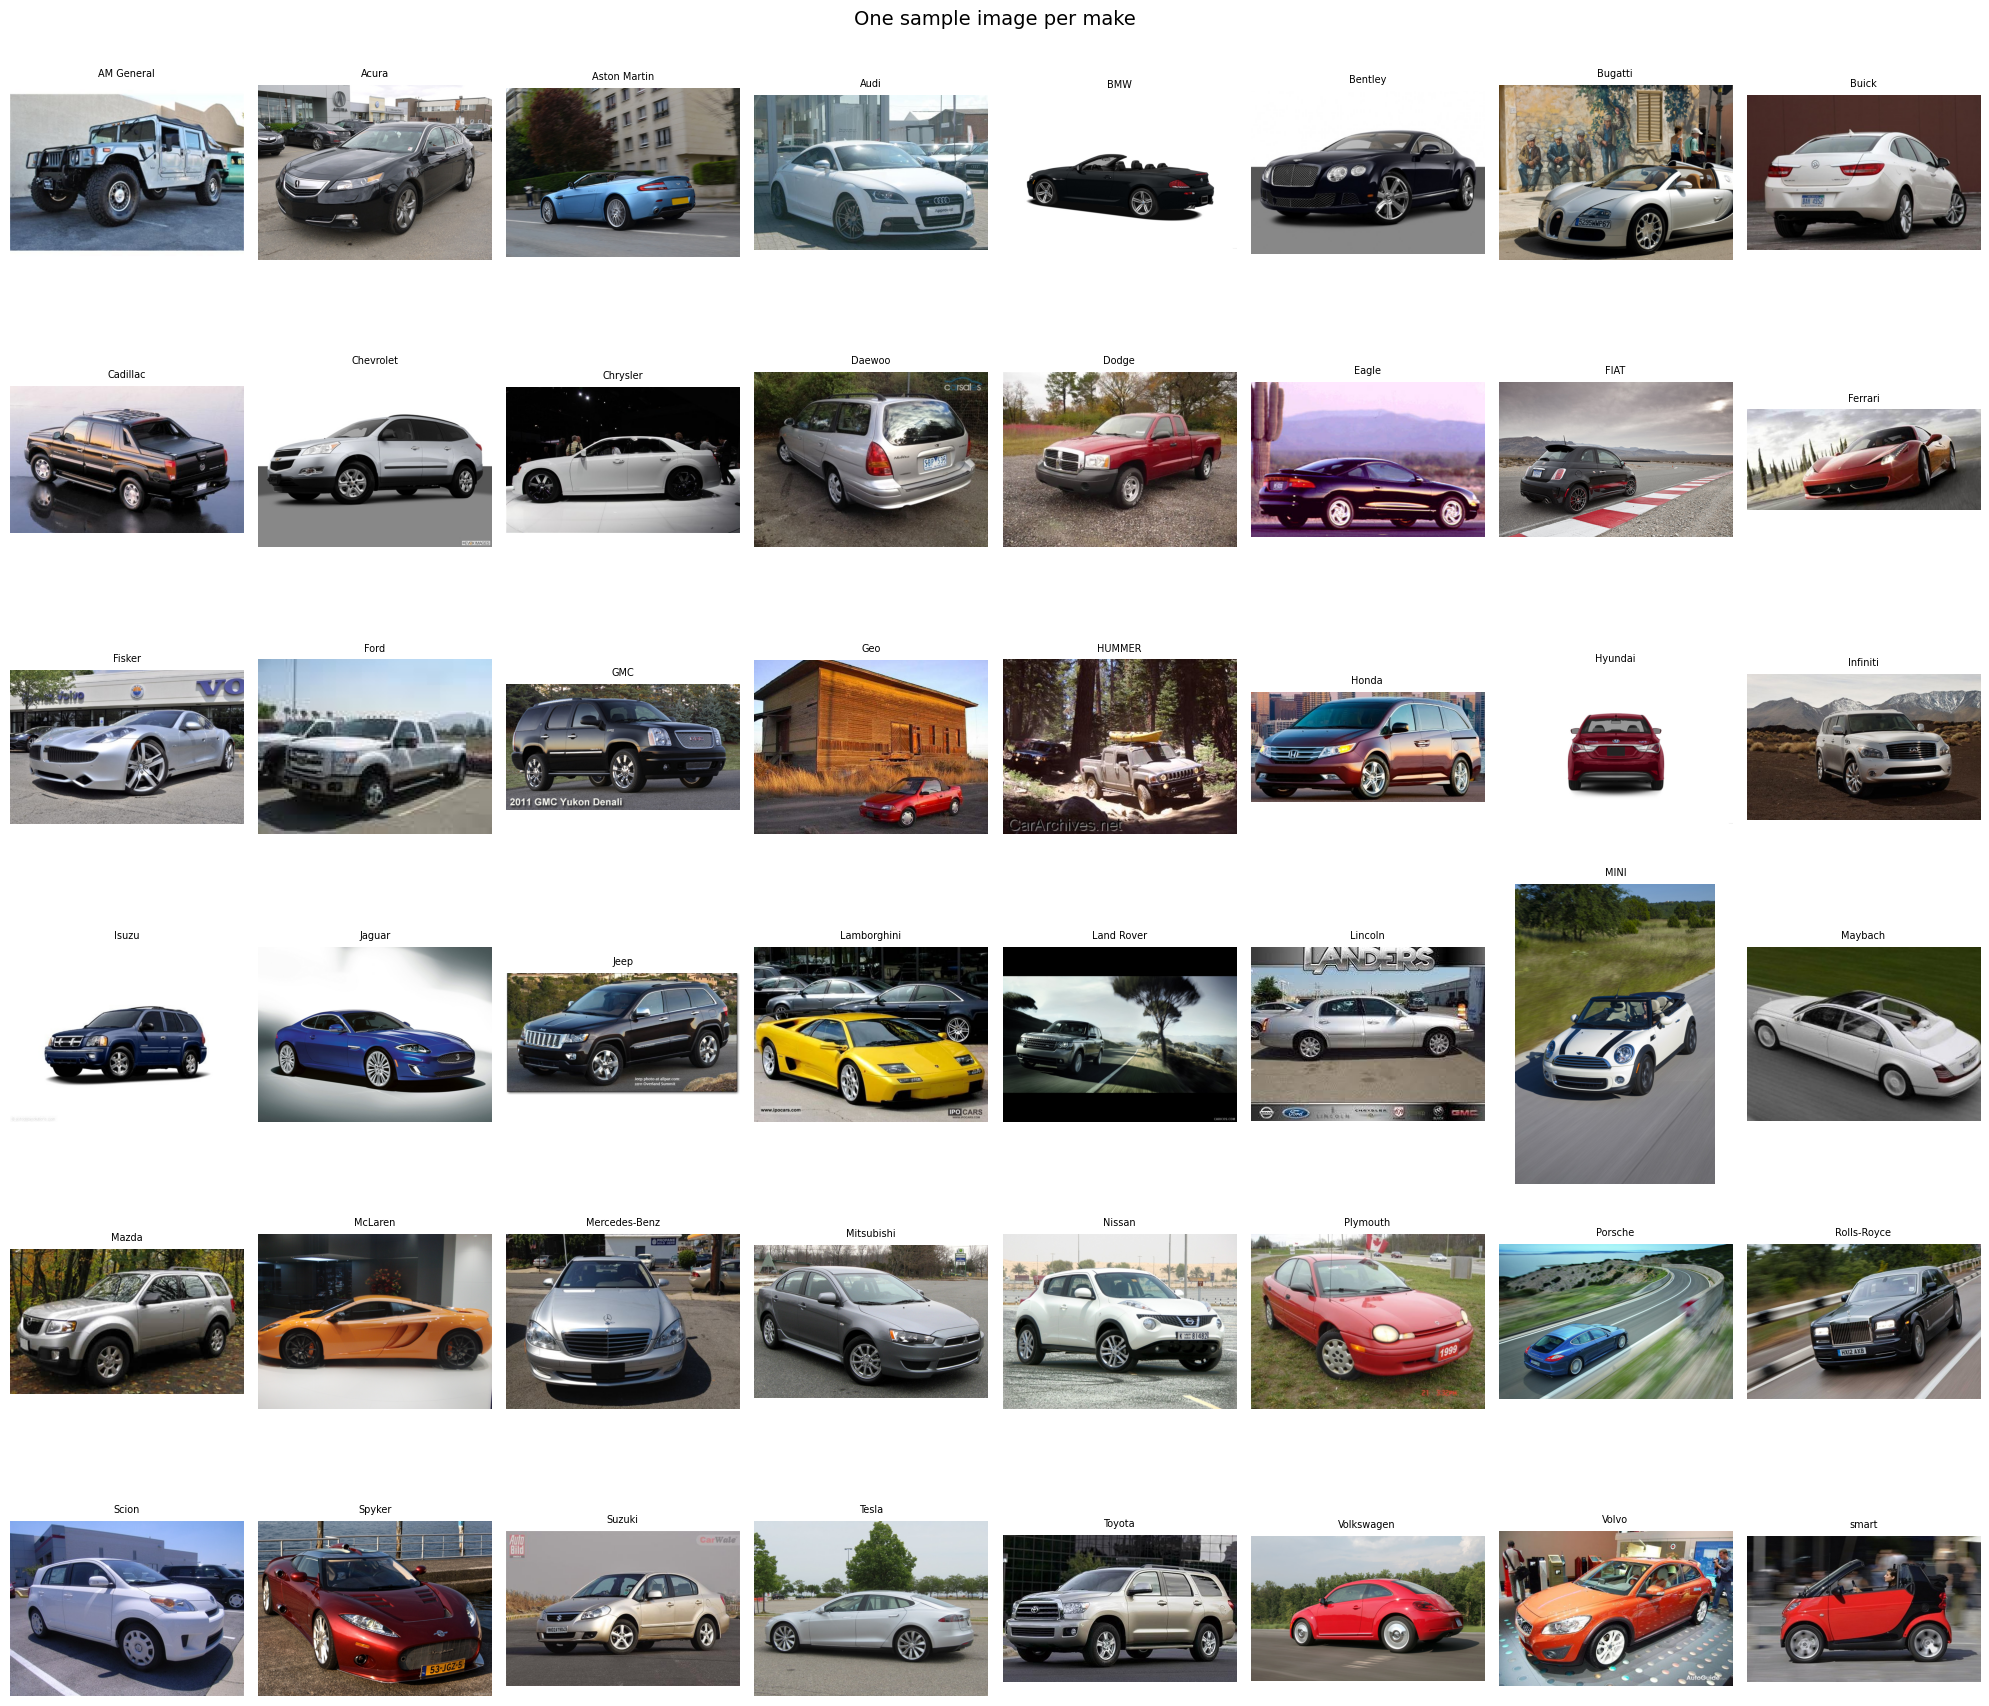

In [14]:
unique_makes = sorted(set(makes))
make_to_idx = {}

for idx, (name, make) in enumerate(zip(dataset['train']['car_name'], makes)):
    if make not in make_to_idx:
        make_to_idx[make] = idx
    if len(make_to_idx) == len(unique_makes):
        break

n = len(unique_makes)
cols = 8
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 3))
axes = axes.flatten()

for i, make in enumerate(sorted(make_to_idx)):
    img = dataset['train'][make_to_idx[make]]['image_path']
    axes[i].imshow(img)
    axes[i].set_title(make, fontsize=7)
    axes[i].axis('off')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('One sample image per make', fontsize=14)
plt.tight_layout()
plt.show()


In [15]:
print(sorted(set(makes)))

['AM General', 'Acura', 'Aston Martin', 'Audi', 'BMW', 'Bentley', 'Bugatti', 'Buick', 'Cadillac', 'Chevrolet', 'Chrysler', 'Daewoo', 'Dodge', 'Eagle', 'FIAT', 'Ferrari', 'Fisker', 'Ford', 'GMC', 'Geo', 'HUMMER', 'Honda', 'Hyundai', 'Infiniti', 'Isuzu', 'Jaguar', 'Jeep', 'Lamborghini', 'Land Rover', 'Lincoln', 'MINI', 'Maybach', 'Mazda', 'McLaren', 'Mercedes-Benz', 'Mitsubishi', 'Nissan', 'Plymouth', 'Porsche', 'Rolls-Royce', 'Scion', 'Spyker', 'Suzuki', 'Tesla', 'Toyota', 'Volkswagen', 'Volvo', 'smart']


## CompCars Dataset - Domain Gap Exploration

Stanford Cars is useful because it has clean make/model/year labels, but many images are catalog-style or controlled vehicle photos.

The real TwinCar use case is different. Production images may come from drones and ground robots in parking lots or inspection environments. These images can include:

- different camera angles
- side, rear, front, and oblique views
- shadows and reflections
- background cars and infrastructure
- partial occlusion
- different image resolutions

We explored a filtered CompCars subset to understand these real-world visual conditions.

Important decision:

**CompCars will not be merged into the main training dataset at this stage.**

Reason:

The available filtered CompCars data is mainly organized by make IDs and viewpoints, while our main Stanford Cars task uses make/model/year classes. Merging them directly could introduce label noise or inconsistent classes.

Instead, CompCars is used as domain-gap evidence. It helps us decide what kind of data augmentation is useful, for example lighting changes, viewpoint variation, and mild occlusion.

In [17]:
COMPCARS_PATH = f'{PROJECT_ROOT}/compcars_filtered'
make_folders = sorted(os.listdir(COMPCARS_PATH))
print(f'Number of make folders: {len(make_folders)}')
print(f'Make IDs found: {make_folders}')

Number of make folders: 42
Make IDs found: ['.DS_Store', '100', '101', '11', '111', '112', '118', '122', '131', '134', '139', '142', '143', '144', '145', '149', '15', '154', '162', '21', '22', '26', '28', '30', '39', '42', '48', '50', '51', '53', '54', '57', '6', '7', '73', '77', '78', '81', '83', '85', '92', '97']


In [21]:
make_model_name = {
    6: 'Fisker',
    7: 'GMC',
    11: 'Jeep',
    15: 'MINI',
    21: 'Scion',
    22: 'Tesla',
    26: 'smart',
    28: 'Mitsubishi',
    30: 'Spyker',
    39: 'Toyota',
    42: 'Isuzu',
    48: 'Porsche',
    50: 'Chrysler',
    51: 'Lamborghini',
    53: 'Cadillac',
    54: 'Buick',
    57: 'Rolls-Royce',
    73: 'Volkswagen',
    77: 'Mercedes-Benz',
    78: 'Audi',
    81: 'BMW',
    83: 'Bentley',
    85: 'Bugatti',
    92: 'Jaguar',
    97: 'Nissan',
    100: 'Honda',
    101: 'Lincoln',
    111: 'Volvo',
    112: 'Ferrari',
    118: 'Hyundai',
    122: 'Ford',
    131: 'Infiniti',
    134: 'FIAT',
    139: 'Acura',
    142: 'Land Rover',
    143: 'McLaren',
    144: 'Maybach',
    145: 'Dodge',
    149: 'Suzuki',
    154: 'Aston Martin',
    162: 'Mazda',
}

make_folders = os.listdir(COMPCARS_PATH)

compcars_make_counts = {}
compcars_total = 0

for make_id_str in make_folders:
    if not make_id_str.isdigit():
        continue

    make_id = int(make_id_str)
    make_name = make_model_name.get(make_id, f'unknown_{make_id}')
    make_path = os.path.join(COMPCARS_PATH, make_id_str)

    image_count = 0

    for root, dirs, files in os.walk(make_path):
        image_count += sum(
            1 for file in files
            if file.lower().endswith(('.jpg', '.jpeg', '.png'))
        )

    compcars_make_counts[make_name] = image_count
    compcars_total += image_count

print(f'Total CompCars filtered images: {compcars_total}')
print('\nImages per make:')

for make, count in sorted(compcars_make_counts.items(), key=lambda x: -x[1]):
    print(f'  {make}: {count}')


Total CompCars filtered images: 34491

Images per make:
  Volkswagen: 2942
  Mercedes-Benz: 2625
  Audi: 2489
  BMW: 2373
  Toyota: 2338
  Ford: 1930
  Nissan: 1866
  Hyundai: 1849
  Honda: 1174
  Mazda: 1157
  Volvo: 1156
  Buick: 1036
  Suzuki: 972
  Mitsubishi: 930
  MINI: 833
  Infiniti: 786
  FIAT: 737
  Dodge: 617
  Porsche: 581
  Cadillac: 541
  Acura: 532
  Aston Martin: 520
  Jeep: 483
  Land Rover: 482
  Jaguar: 440
  Ferrari: 364
  Chrysler: 360
  Lincoln: 344
  Lamborghini: 304
  GMC: 280
  Bentley: 234
  smart: 208
  Scion: 185
  Rolls-Royce: 185
  McLaren: 179
  Tesla: 117
  Spyker: 86
  Fisker: 84
  Bugatti: 83
  Isuzu: 67
  Maybach: 22


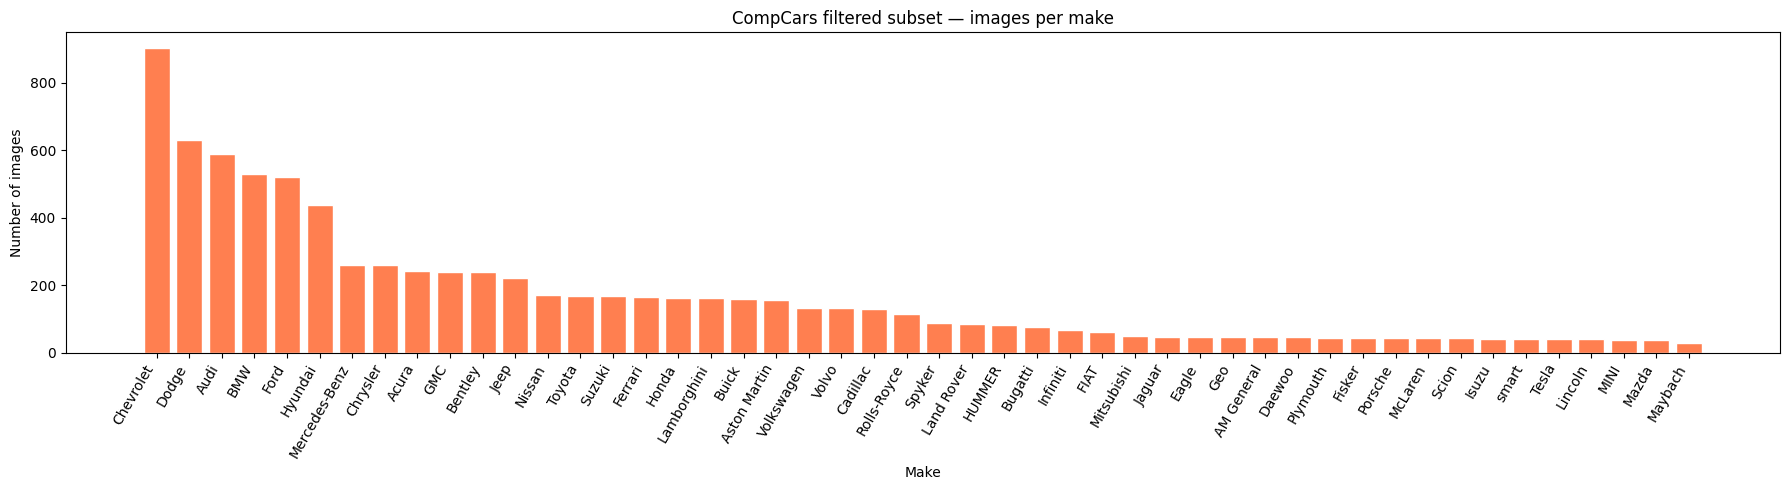

In [22]:
makes_sorted = sorted(make_counts, key=make_counts.get, reverse=True)
counts_sorted = [make_counts[m] for m in makes_sorted]

plt.figure(figsize=(18, 5))
plt.bar(makes_sorted, counts_sorted, color='coral', edgecolor='white')
plt.title('CompCars filtered subset — images per make')
plt.xlabel('Make')
plt.ylabel('Number of images')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

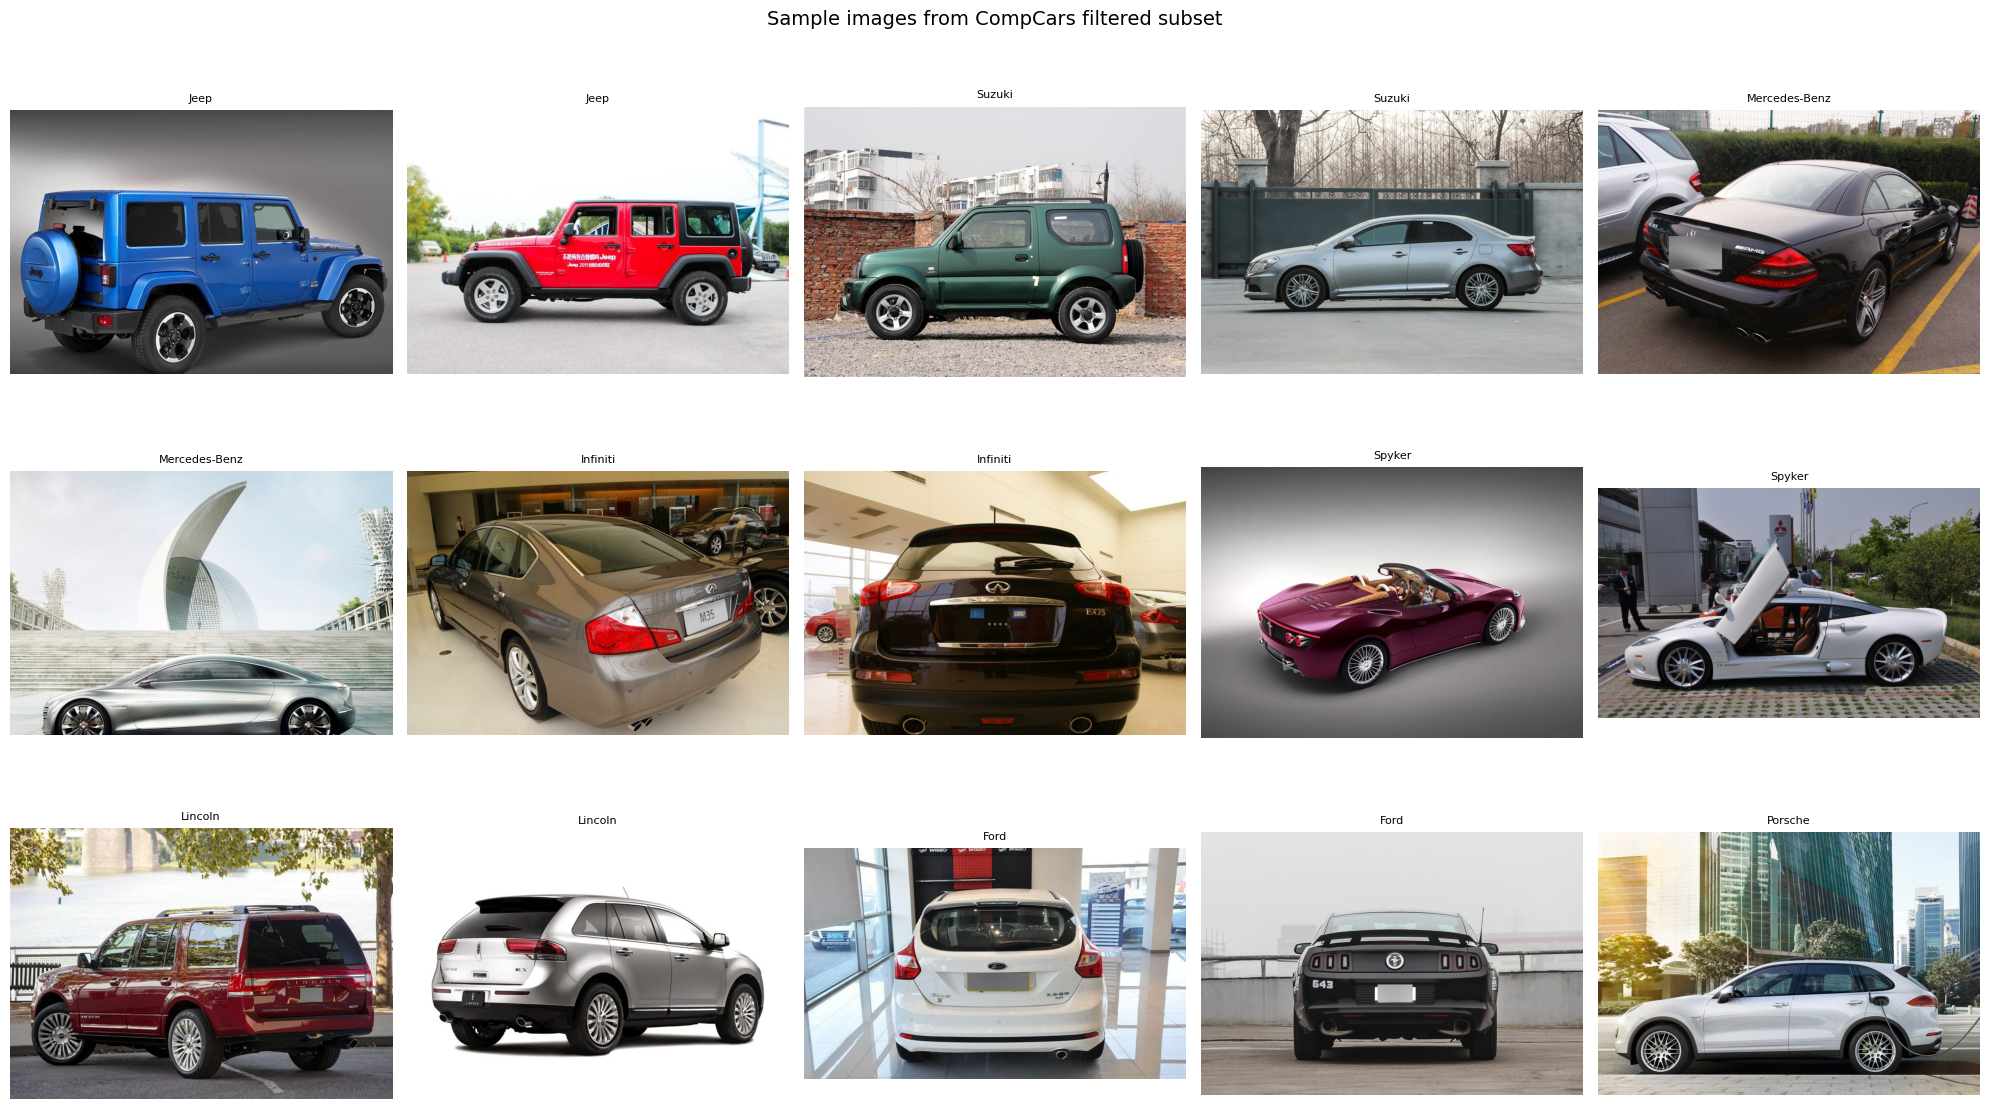

In [23]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

sampled = 0
for make_id_str in random.sample(make_folders, 10):
    if make_id_str == '.DS_Store':
        continue
    make_path = os.path.join(COMPCARS_PATH, make_id_str)
    all_images = []
    for root, dirs, files in os.walk(make_path):
        for f in files:
            if f.endswith('.jpg'):
                all_images.append(os.path.join(root, f))
    if not all_images:
        continue
    for img_path in random.sample(all_images, min(2, len(all_images))):
        img = Image.open(img_path)
        make_name = make_model_name.get(int(make_id_str), make_id_str)
        axes[sampled].imshow(img)
        axes[sampled].set_title(make_name, fontsize=8)
        axes[sampled].axis('off')
        sampled += 1
        if sampled == 15:
            break
    if sampled == 15:
        break

plt.suptitle('Sample images from CompCars filtered subset', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
all_images = []
for root, dirs, files in os.walk(COMPCARS_PATH):
    for f in files:
        if f.endswith('.jpg'):
            all_images.append(os.path.join(root, f))

sample_paths = random.sample(all_images, 500)
widths, heights = [], []

for path in sample_paths:
    img = Image.open(path)
    w, h = img.size
    widths.append(w)
    heights.append(h)

print(f'Width  - min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}')
print(f'Height - min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}')

Width  - min: 683, max: 1024, mean: 861
Height - min: 416, max: 1033, mean: 594


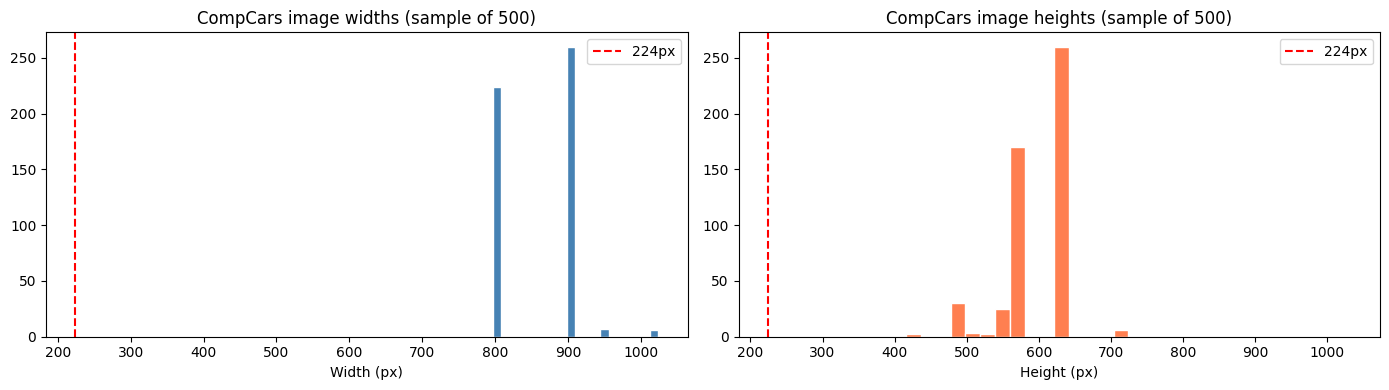

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(widths, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('CompCars image widths (sample of 500)')
axes[0].set_xlabel('Width (px)')
axes[0].axvline(x=224, color='red', linestyle='--', label='224px')
axes[0].legend()

axes[1].hist(heights, bins=30, color='coral', edgecolor='white')
axes[1].set_title('CompCars image heights (sample of 500)')
axes[1].set_xlabel('Height (px)')
axes[1].axvline(x=224, color='red', linestyle='--', label='224px')
axes[1].legend()

plt.tight_layout()
plt.show()

### CompCars observations

- CompCars images are useful for understanding real-world variation in vehicle photos.
- Compared with Stanford Cars, CompCars contains more diverse viewpoints and more realistic backgrounds.
- This supports the decision to use data augmentation during training.
- However, because the available CompCars subset is not cleanly aligned with Stanford make/model/year labels, it will not be merged into the training dataset in this baseline version.
- Instead, it is used to justify augmentations such as brightness/contrast changes, mild rotation, perspective variation, and partial occlusion.

## Final EDA Summary and Dataset Strategy

| Topic | Decision |
|---|---|
| Main training dataset | Stanford Cars |
| Number of classes | Make/model/year class labels from Stanford Cars |
| Mandatory prediction target | Make + model |
| Optional target | Year |
| Validation strategy | Stratified split from the Stanford train split |
| Test strategy | Keep the official Stanford test split untouched |
| CompCars usage | Domain-gap exploration only |
| Why not merge CompCars now? | Label mismatch and risk of noisy make/model classes |
| Image preprocessing | Resize/crop to fixed input size for pretrained CNN |
| Augmentation motivation | Realistic variation: lighting, shadows, viewpoint, scale, mild occlusion |

### Final decision

For the first working baseline, we will train on Stanford Cars only.

CompCars will not be used as extra training data in this version. It is used only to understand how real-world TwinCar images may differ from clean public dataset images.

This keeps the first model simpler, cleaner, and easier to evaluate.